In [76]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [77]:
PATH = "../dataset_tp1/"

def load_set(name):
    labels = pd.read_csv(PATH + f"{name}_labels.csv")
    imgs = []
    for file in labels["archivo"]:
        img = Image.open(PATH + f"{name}/{file}").convert("L")
        vector = np.array(img, dtype=float).ravel() / 255 #Normalizamos los valores entre 0 y 1 (mejora la convergencia)
        imgs.append(vector)
    X = np.stack(imgs)
    y = labels["clase"].values
    return X, y

In [78]:
X_train, y_train = load_set("train")
mu_train = X_train.mean(axis=0)
centered_x = X_train - mu_train
U, S, V_t = np.linalg.svd(centered_x, full_matrices=False)
V = np.transpose(V_t)
V2 = V[:, :2]

In [79]:
def project(X):
    return (X - mu_train) @ V2

In [80]:
Y_train = project(X_train)
X_test, y_test = load_set("test")
Y_test = project(X_test)

model = LogisticRegression(max_iter=2000)

model.fit(Y_train, y_train)
y_pred = model.predict(Y_test)
A0 = accuracy_score(y_test, y_pred)
print(A0)

0.8034188034188035


In [81]:
def rotate_image(x):
    img_matrix = x.reshape(128, 128)
    rotated_x = np.rot90(img_matrix, 2)
    return rotated_x.ravel()

In [82]:
rng = np.random.default_rng(seed=0)
n_test = X_test.shape[0]

def raffle(n, p):
    # n uniformes U(0,1) independientes; U < p es una Bernoulli(p)
    return rng.random(n) < p

In [83]:
def perturb_images(imgs_mtx, mask):
    # Rota 180° las filas donde mask es True; no modifica imgs_mtx
    perturbed = imgs_mtx.copy()
    for i in np.where(mask)[0]:
        perturbed[i] = rotate_image(imgs_mtx[i])
    return perturbed

### Simulación Monte Carlo

El clasificador predice cada imagen por separado y cada imagen de test solo puede estar derecha o rotada. Por eso alcanza con calcular una vez la predicción de cada imagen en sus dos estados; en cada realización se elige, imagen por imagen, cuál de las dos usar según el sorteo. La celda siguiente comprueba que esto da exactamente lo mismo que rotar, proyectar y predecir en cada realización.

In [84]:
X_test_rot = perturb_images(X_test, np.ones(n_test, dtype=bool))  # todo el test rotado
pred_orig = model.predict(project(X_test))
pred_rot = model.predict(project(X_test_rot))

def realization_accuracy(p):
    mask = raffle(n_test, p)
    pred = np.where(mask, pred_rot, pred_orig)
    return np.mean(pred == y_test)

def monte_carlo(p, n_mc):
    return np.array([realization_accuracy(p) for _ in range(n_mc)])

In [85]:
# Verificación: el método directo y el precalculado coinciden para las mismas máscaras
for p_check in [0.1, 0.5, 0.9]:
    mask = raffle(n_test, p_check)
    pred_direct = model.predict(project(perturb_images(X_test, mask)))
    pred_fast = np.where(mask, pred_rot, pred_orig)
    print(f"p = {p_check}: predicciones idénticas -> {np.array_equal(pred_direct, pred_fast)}")

p = 0.1: predicciones idénticas -> True
p = 0.5: predicciones idénticas -> True
p = 0.9: predicciones idénticas -> True


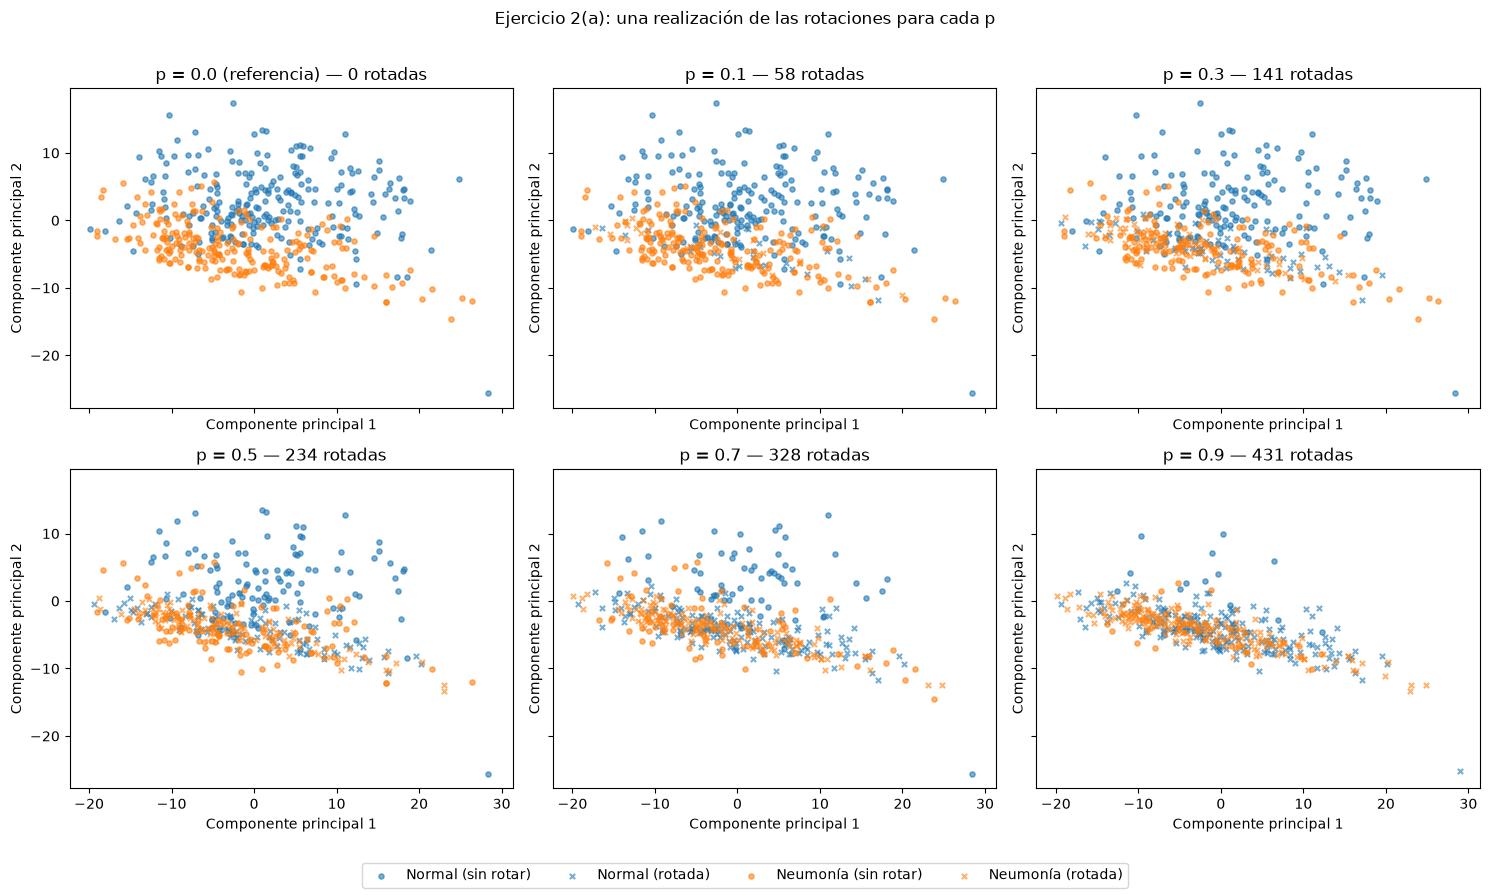

In [86]:
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]   # para scatters e histogramas
p_scatter = [0.0] + p_values            # p = 0 se usa solo como referencia (test sin rotar)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for ax, p_case in zip(axes.flat, p_scatter):
    mask = raffle(n_test, p_case)
    Y_case = project(perturb_images(X_test, mask))
    for clase, nombre, color in [(0, "Normal", "tab:blue"), (1, "Neumonía", "tab:orange")]:
        for rotada, marcador, texto in [(False, "o", "sin rotar"), (True, "x", "rotada")]:
            filas = (y_test == clase) & (mask == rotada)
            ax.scatter(Y_case[filas, 0], Y_case[filas, 1], s=14, alpha=0.6,
                       color=color, marker=marcador, label=f"{nombre} ({texto})")
    titulo = f"p = {p_case:.1f}" + (" (referencia)" if p_case == 0 else "") + f" — {mask.sum()} rotadas"
    ax.set_title(titulo)
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")

handles, labels = axes.flat[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
fig.suptitle("Ejercicio 2(a): una realización de las rotaciones para cada p")
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

In [87]:
N_MC = 2000
eps = 0.05
# Cota de Chebyshev para el estimador de una probabilidad: Var <= 1/(4 N_MC)
print(f"Desvío máximo del estimador de probabilidad: {np.sqrt(1 / (4 * N_MC)):.4f}")
print(f"Cota P(|error| >= {eps}) <= {1 / (4 * N_MC * eps**2):.3f}")

p_fine = [round(float(p), 2) for p in np.arange(0.05, 0.91, 0.05)]  # grilla fina para (b) y (c)
acc_by_p = {p_case: monte_carlo(p_case, N_MC) for p_case in p_fine}

Desvío máximo del estimador de probabilidad: 0.0112
Cota P(|error| >= 0.05) <= 0.050


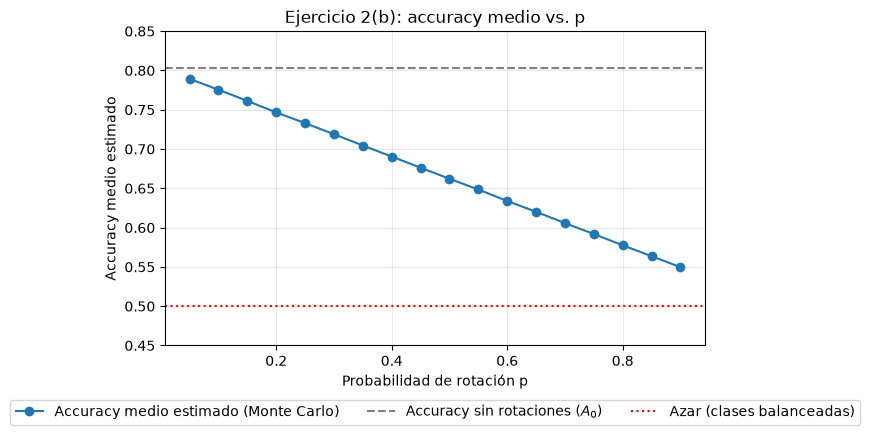

In [88]:
mean_accuracy = [acc_by_p[p_case].mean() for p_case in p_fine]

plt.figure(figsize=(8, 4.5))
plt.plot(p_fine, mean_accuracy, marker="o", label="Accuracy medio estimado (Monte Carlo)")
plt.axhline(A0, color="gray", linestyle="--", label="Accuracy sin rotaciones ($A_0$)")
plt.axhline(0.5, color="red", linestyle=":", label="Azar (clases balanceadas)")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Accuracy medio estimado")
plt.title("Ejercicio 2(b): accuracy medio vs. p")
plt.ylim(0.45, 0.85)
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()

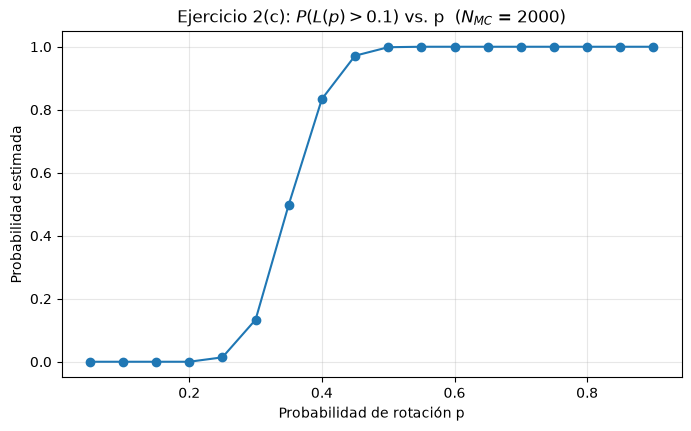

In [89]:
delta = 0.1
prob_loss = [np.mean((A0 - acc_by_p[p_case]) > delta) for p_case in p_fine]

plt.figure(figsize=(8, 4.5))
plt.plot(p_fine, prob_loss, marker="o")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Probabilidad estimada")
plt.title(rf"Ejercicio 2(c): $P(L(p) > {delta})$ vs. p  ($N_{{MC}}$ = {N_MC})")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.show()

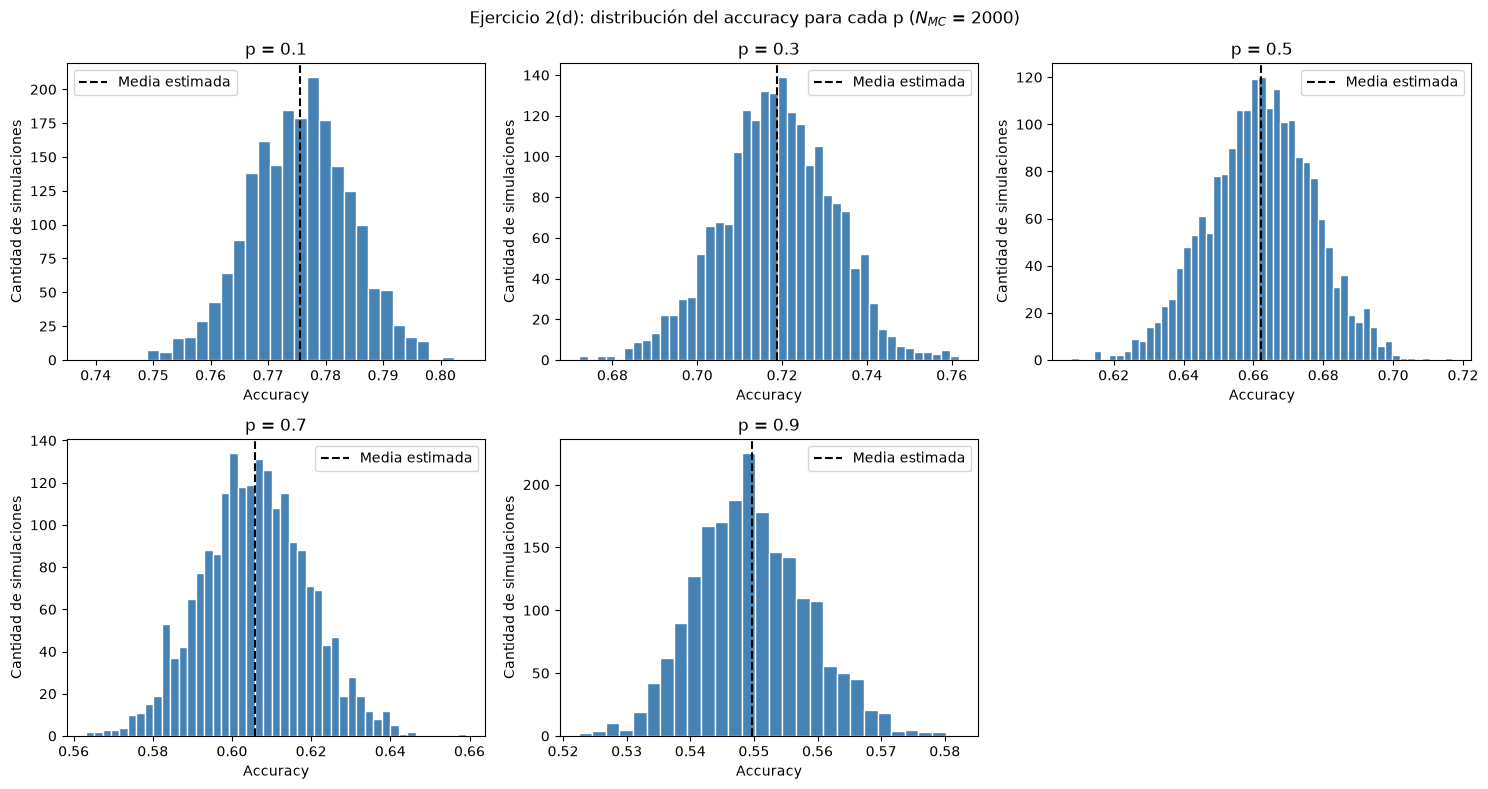

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, p_case in zip(axes.flat, p_values):
    acc = acc_by_p[p_case]
    # El accuracy solo toma valores k/n_test: un intervalo centrado en cada valor posible
    k_min = round(acc.min() * n_test)
    k_max = round(acc.max() * n_test)
    bins = (np.arange(k_min, k_max + 2) - 0.5) / n_test
    ax.hist(acc, bins=bins, color="steelblue", edgecolor="white")
    ax.axvline(acc.mean(), color="black", linestyle="--", label="Media estimada")
    ax.set_title(f"p = {p_case:.1f}")
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Cantidad de simulaciones")
    ax.legend()
axes.flat[-1].axis("off")
fig.suptitle(f"Ejercicio 2(d): distribución del accuracy para cada p ($N_{{MC}}$ = {N_MC})")
fig.tight_layout()
plt.show()

### Estabilidad de las estimaciones Monte Carlo

Para `p = 0.3`, estos gráficos muestran cómo cambian el accuracy medio y la probabilidad estimada de una pérdida mayor que `0.1` al acumular simulaciones. Usan los resultados ya generados; no hacen sorteos adicionales.

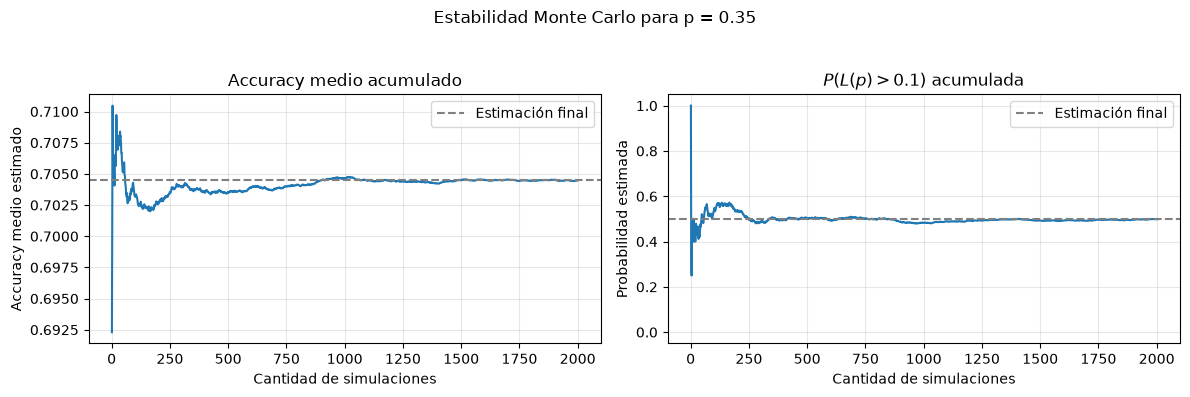

In [101]:
p_extra = 0.35
acc_extra = np.asarray(acc_by_p[p_extra])
trials = np.arange(1, len(acc_extra) + 1)
running_acc = np.cumsum(acc_extra) / trials
loss_events = (A0 - acc_extra > delta).astype(int)
running_prob = np.cumsum(loss_events) / trials

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(trials, running_acc)
axes[0].axhline(acc_extra.mean(), color="gray", linestyle="--", label="Estimación final")
axes[0].set_xlabel("Cantidad de simulaciones")
axes[0].set_ylabel("Accuracy medio estimado")
axes[0].set_title("Accuracy medio acumulado")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(trials, running_prob)
axes[1].axhline(loss_events.mean(), color="gray", linestyle="--", label="Estimación final")
axes[1].set_xlabel("Cantidad de simulaciones")
axes[1].set_ylabel("Probabilidad estimada")
axes[1].set_title(r"$P(L(p) > 0.1)$ acumulada")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_yticks(np.linspace(0, 1, 6))
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"Estabilidad Monte Carlo para p = {p_extra}")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()